In [2]:
from google.colab import files
uploaded = files.upload()

Saving otsu.webp to otsu.webp
Saving harris.webp to harris.webp


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

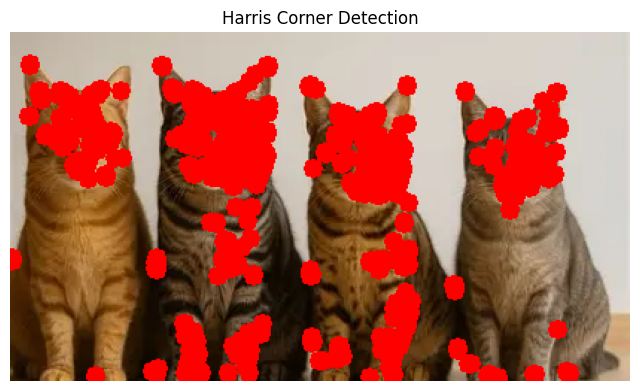

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the Harris image
image = cv2.imread('harris.webp')

if image is None:
    print("Image not found. Check the file name.")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    # Apply Harris Corner Detection
    harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # Dilate to make corners clearer
    harris = cv2.dilate(harris, None)

    # Threshold to detect strong corners
    threshold = 0.01 * harris.max()
    corner_coords = np.argwhere(harris > threshold)

    # Draw red circles on detected corners
    for y, x in corner_coords:
        cv2.circle(image, (x, y), radius=5, color=(0, 0, 255), thickness=-1)

    # Show the result
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Harris Corner Detection')
    plt.axis('off')
    plt.show()

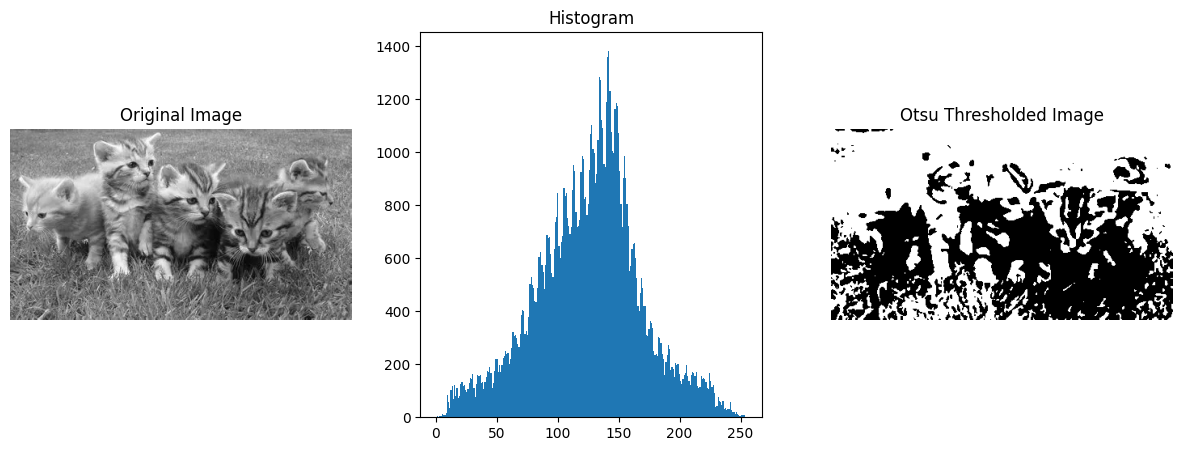

Otsu threshold value: 122.0


In [5]:
import cv2
import matplotlib.pyplot as plt

# Load the Otsu image in grayscale
img = cv2.imread('otsu.webp', 0)

if img is None:
    print("Image not found. Check the file name.")
else:
    # Blur the image slightly to improve thresholding
    blur = cv2.GaussianBlur(img, (5,5), 0)

    # Apply Otsu thresholding
    ret, thresh_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Show original image, histogram, and thresholded image
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.hist(img.ravel(), bins=256)
    plt.title('Histogram')

    plt.subplot(1,3,3)
    plt.imshow(thresh_img, cmap='gray')
    plt.title('Otsu Thresholded Image')
    plt.axis('off')

    plt.show()

    print("Otsu threshold value:", ret)